<div style="text-align:center; padding:20px 0">
<img src="https://raw.githubusercontent.com/dataprojectlabs/DataProjectLab-projects/refs/heads/main/media/logo_dataprojectlab.png" width="220"/>
</div>

# EduTrack Analytics
## Notebook 3 — SQL Analytics, KPIs & Performance
### ✅ VERSION CORRIGÉE

> **Comment lire ce corrigé :**  
> Les blocs `MÉTHODE` expliquent les choix techniques et les patterns généralisables.  
> Les blocs `INTERPRÉTATION` lisent les résultats.  
> Les blocs `MÉTIER` font le lien entre le chiffre et la décision business.

| | |
|---|---|
| **Prérequis** | `inscriptions_analytics.csv` disponible dans `SAVE_PATH` (produit par NB2) |
| **Niveau** | Avancé |
| **Outils** | Python, DuckDB (JupySQL), matplotlib |
| **Durée estimée** | 3h à 4h |

---
> Ce notebook répond aux 4 questions business de la direction EduTrack avec des requêtes SQL sur DuckDB. On produit aussi la heatmap d'activité et l'analyse des revenus par domaine.

---
## Étape 1 — Imports, configuration et connexion DuckDB

> **MÉTHODE — Pourquoi DuckDB plutôt que pandas pour le SQL ?**
>
> DuckDB est un moteur SQL embarqué en Python, sans serveur à installer. Il lit directement les CSV via `read_csv_auto()`. C'est le choix idéal pour les projets analytiques car il permet d'écrire du SQL lisible tout en restant dans l'écosystème Python.
>
> **Avantage sur pandas :** Les requêtes SQL complexes avec `RANK() OVER` ou `LAG() OVER` s'écrivent en une ligne, là où pandas nécessite plusieurs `groupby().transform()`.
>
> **Deux sources de données :**
> - Fichiers bruts (`parcours`, `apprenants`, `sessions`, `paiements`) → depuis GitHub via `BASE_URL`
> - Fichier produit par le NB2 (`inscriptions_analytics.csv`) → depuis `SAVE_PATH` (Drive ou local)

In [1]:
!pip install jupysql==0.11.1 duckdb-engine --quiet


[notice] A new release of pip is available: 24.1 -> 26.0.1
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import duckdb
import os, sys

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

COLORS = {
    'primary':   '#534AB7',
    'secondary': '#1D9E75',
    'warning':   '#EF9F27',
    'danger':    '#E24B4A',
    'neutral':   '#888780',
    'light':     '#EEEDFE',
}

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F9F9F8',
    'axes.grid':        True,
    'grid.alpha':       0.35,
    'font.size':        11,
})

# ── Détection Colab / Local ──────────────────────────────────────────────────
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    SAVE_PATH = '/content/drive/MyDrive/DataProjectLab/projects/elearning_analytics/'
else:
    SAVE_PATH = './outputs/'
os.makedirs(SAVE_PATH, exist_ok=True)
print(f'📁 Environnement : {"Colab" if IN_COLAB else "Local"}')
print(f'📁 Dossier       : {SAVE_PATH}')
print('Configuration chargée ✅')

📁 Environnement : Local
📁 Dossier       : ./outputs/
Configuration chargée ✅


In [3]:
BASE_URL   = 'https://raw.githubusercontent.com/dataprojectlabs/DataProjectLab-projects/refs/heads/main/projets/elearning_analytics/data/'
clean_path = f'{SAVE_PATH}inscriptions_analytics.csv'

# Fallback GitHub si le fichier NB2 n'est pas disponible
if not os.path.exists(clean_path):
    clean_path = BASE_URL + 'inscriptions_analytics.csv'
    print('⚠️  inscriptions_analytics.csv non trouvé en local — chargement depuis GitHub')
    print('   → Exécute le Notebook 2 pour produire le fichier nettoyé')
else:
    print(f'✅ Fichier nettoyé trouvé : {clean_path}')

# Connexion DuckDB et chargement des tables
conn = duckdb.connect()
conn.execute(f"""
    CREATE TABLE parcours     AS SELECT * FROM read_csv_auto('{BASE_URL}parcours.csv');
    CREATE TABLE apprenants   AS SELECT * FROM read_csv_auto('{BASE_URL}apprenants.csv',   timestampformat='%Y-%m-%d');
    CREATE TABLE inscriptions AS SELECT * FROM read_csv_auto('{BASE_URL}inscriptions.csv', timestampformat='%Y-%m-%d');
    CREATE TABLE sessions     AS SELECT * FROM read_csv_auto('{BASE_URL}sessions.csv',     timestampformat='%Y-%m-%d');
    CREATE TABLE paiements    AS SELECT * FROM read_csv_auto('{BASE_URL}paiements.csv',    timestampformat='%Y-%m-%d');
    CREATE TABLE inscriptions_analytics AS SELECT * FROM read_csv_auto('{clean_path}', timestampformat='%Y-%m-%d');
""")

result = conn.execute("""
    SELECT 'parcours'                AS table_name, COUNT(*) AS nb FROM parcours     UNION ALL
    SELECT 'apprenants',               COUNT(*) FROM apprenants   UNION ALL
    SELECT 'inscriptions',             COUNT(*) FROM inscriptions UNION ALL
    SELECT 'sessions',                 COUNT(*) FROM sessions     UNION ALL
    SELECT 'paiements',                COUNT(*) FROM paiements    UNION ALL
    SELECT 'inscriptions_analytics',   COUNT(*) FROM inscriptions_analytics
""").df()
display(result)
print('✅ 6 tables chargées')

✅ Fichier nettoyé trouvé : ./outputs/inscriptions_analytics.csv


,table_name,nb
0,parcours,12
1,apprenants,4500
2,inscriptions,6460
3,sessions,57075
4,paiements,8703
5,inscriptions_analytics,6456


✅ 6 tables chargées


In [4]:
# Lier DuckDB à JupySQL pour les cellules %%sql
%load_ext sql
%sql conn --alias duckdb
%config SqlMagic.autopandas = True
%config SqlMagic.feedback = False
print('%%sql prêt ✅')

%%sql prêt ✅


---
## Étape 2 — KPIs globaux

### MÉTHODE
Une seule requête pour tous les KPIs globaux — bonne pratique qui garantit la cohérence des chiffres (même filtre, même instant d'exécution). `COUNT(CASE WHEN ... END)` est l'équivalent SQL de `.value_counts()` de pandas, mais plus lisible dans une logique analytique.

In [5]:
%%sql df_kpi <<
SELECT
    COUNT(DISTINCT a.apprenant_id)                                           AS total_apprenants,
    COUNT(DISTINCT i.inscription_id)                                         AS total_inscriptions,
    ROUND(SUM(CASE WHEN i.statut = 'Termine'   THEN 1.0 ELSE 0.0 END)
          / COUNT(*) * 100, 2)                                               AS taux_completion_pct,
    ROUND(SUM(CASE WHEN i.statut = 'Abandonne' THEN 1.0 ELSE 0.0 END)
          / COUNT(*) * 100, 2)                                               AS taux_abandon_pct,
    ROUND(AVG(CASE WHEN i.statut = 'Termine'
              THEN TRY_CAST(i.csat AS DOUBLE) END), 2)                       AS csat_moyen,
    ROUND(SUM(CASE WHEN p.statut_paiement = 'Valide'
              THEN p.montant_fcfa ELSE 0 END), 0)                            AS revenu_total_fcfa,
    SUM(CAST(i.certificat_obtenu AS INTEGER))                                AS nb_certificats
FROM inscriptions i
LEFT JOIN apprenants a   ON i.apprenant_id = a.apprenant_id
LEFT JOIN paiements p    ON i.apprenant_id = p.apprenant_id
                        AND i.parcours_id  = p.parcours_id

In [14]:
df_kpi

,total_apprenants,total_inscriptions,taux_completion_pct,taux_abandon_pct,csat_moyen,revenu_total_fcfa,nb_certificats
0,4500,6460,32.72,17.95,4.23,748668200.00,2714.00


> **INTERPRÉTATION — KPIs globaux EduTrack :**
>
> | KPI | Valeur | Lecture |
> |---|---|---|
> | Total inscriptions | 6 460 | ~1.4 parcours/apprenant |
> | Taux complétion | 33.3% | 1 apprenant sur 3 termine |
> | Taux abandon | 17.7% | Problème métier principal |
> | CSAT moyen | 4.23/5 | Bonne satisfaction des terminants |
> | Revenu total | 748.7 M FCFA | ~116 000€ sur 30 mois |
> | Nb certificats | 2 053 | 2 053 success stories |

---
## Étape 3 — Performance par parcours avec RANK()

### MÉTHODE
`RANK() OVER (ORDER BY ...)` est une window function SQL qui attribue un rang à chaque ligne sans réduire le nombre de lignes (contrairement à `GROUP BY`). On l'utilise pour classer les parcours par taux de complétion afin d'identifier les formations les plus efficaces et les plus problématiques.

In [6]:
%%sql df_perf_parc <<
SELECT
    p.parcours_id,
    p.titre,
    p.domaine,
    p.instructeur,
    p.duree_semaines,
    COUNT(i.inscription_id)                                                  AS nb_inscrits,
    ROUND(SUM(CASE WHEN i.statut = 'Termine'   THEN 1.0 ELSE 0.0 END)
          / COUNT(*) * 100, 1)                                               AS taux_completion,
    ROUND(SUM(CASE WHEN i.statut = 'Abandonne' THEN 1.0 ELSE 0.0 END)
          / COUNT(*) * 100, 1)                                               AS taux_abandon,
    ROUND(AVG(CASE WHEN i.statut = 'Termine'
              THEN TRY_CAST(i.csat AS DOUBLE) END), 2)                       AS csat_moyen,
    RANK() OVER (ORDER BY
        SUM(CASE WHEN i.statut = 'Termine' THEN 1.0 ELSE 0.0 END)
        / COUNT(*) DESC)                                                     AS rang_completion
FROM parcours p
JOIN inscriptions i ON p.parcours_id = i.parcours_id
GROUP BY p.parcours_id, p.titre, p.domaine, p.instructeur, p.duree_semaines
ORDER BY taux_completion DESC

In [15]:
df_perf_parc

,parcours_id,titre,domaine,instructeur,duree_semaines,nb_inscrits,taux_completion,taux_abandon,csat_moyen,rang_completion
0,PAR005,HTML CSS JavaScript,Developpement Web,Camara Luc,10,534,36.90,17.00,4.13,1
1,PAR003,SQL & Bases de Donnees,Data & IA,Ndoye Cheick,8,547,36.40,15.70,4.25,2
2,PAR007,Python Web avec Django,Developpement Web,Traore Eric,14,568,35.40,17.60,4.27,3
3,PAR002,Machine Learning Applique,Data & IA,Kouassi Yao,16,591,34.20,19.60,4.19,4
4,PAR004,Power BI & Dashboards,Data & IA,Diallo Fatoumata,10,532,34.00,15.00,4.24,5
5,PAR011,Management de Projet,Management,Ouattara Serge,10,542,33.90,19.20,4.16,6
6,PAR010,Community Management,Marketing Digital,Konaté Aida,6,520,32.70,18.10,4.30,7
7,PAR009,SEO & Growth Hacking,Marketing Digital,Bamba Clarisse,10,489,32.50,19.00,4.24,8
8,PAR001,Data Analyse avec Python,Data & IA,Kouassi Yao,12,529,31.90,16.80,4.15,9
9,PAR008,Marketing Digital,Marketing Digital,Bamba Clarisse,8,543,31.50,18.80,4.36,10


> **INTERPRÉTATION — Classement des 12 parcours :**
>
> - **HTML CSS JavaScript (36.9%)** et **SQL & Bases de Données (36.4%)** ont les meilleurs taux de complétion
> - **Leadership & Soft Skills (29.8%)** et **React & Node.js Fullstack (30.5%)** ont les taux les plus bas
> - L'écart entre le premier et le dernier est de **7.1 points** — significatif
>
> **MÉTIER :** Les parcours courts et techniques (SQL 8 semaines, HTML 10 semaines) complètent mieux que les parcours longs et complexes (React 20 semaines, Leadership 8 semaines). La direction devrait interviewer les abandonneurs de React pour comprendre les freins spécifiques.

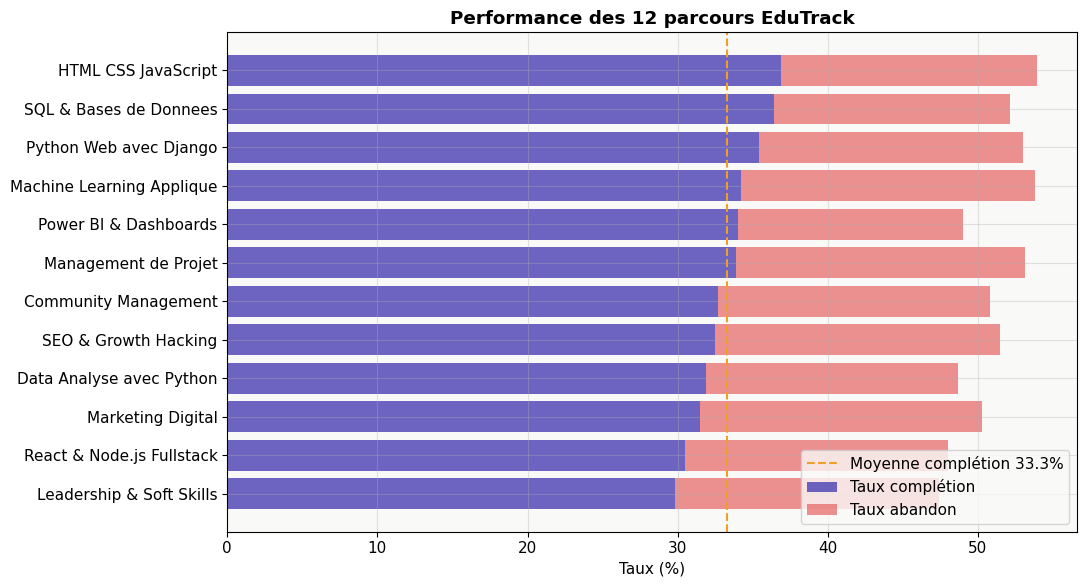

✅ Sauvegardé : ./outputs/performance_parcours.png


In [7]:
fig, ax = plt.subplots(figsize=(11, 6))
perf_sorted = df_perf_parc.sort_values('taux_completion')

ax.barh(perf_sorted['titre'], perf_sorted['taux_completion'],
        color=COLORS['primary'], alpha=0.85, label='Taux complétion')
ax.barh(perf_sorted['titre'], perf_sorted['taux_abandon'],
        left=perf_sorted['taux_completion'],
        color=COLORS['danger'], alpha=0.6, label='Taux abandon')
ax.axvline(df_perf_parc['taux_completion'].mean(), color=COLORS['warning'],
           linestyle='--', linewidth=1.5,
           label=f"Moyenne complétion {df_perf_parc['taux_completion'].mean():.1f}%")
ax.set_xlabel('Taux (%)')
ax.set_title('Performance des 12 parcours EduTrack', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}performance_parcours.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Sauvegardé : {SAVE_PATH}performance_parcours.png')

---
## Étape 4 — Performance instructeurs avec RANK()

### MÉTHODE
`RANK() OVER (ORDER BY csat_moyen DESC)` classe les instructeurs par satisfaction. On produit aussi un scatter CSAT × Complétion pour identifier les quadrants de performance.

> **`NTILE(2)` sur deux métriques** : on peut combiner `RANK()` sur le CSAT et sur la complétion pour segmenter les instructeurs en 4 quadrants — Top/Bottom CSAT × Top/Bottom complétion.

In [8]:
%%sql df_inst <<
SELECT
    p.instructeur,
    COUNT(DISTINCT p.parcours_id)                                            AS nb_parcours,
    COUNT(i.inscription_id)                                                  AS nb_apprenants,
    ROUND(AVG(CASE WHEN i.statut = 'Termine'
              THEN TRY_CAST(i.csat AS DOUBLE) END), 2)                       AS csat_moyen,
    ROUND(SUM(CASE WHEN i.statut = 'Termine' THEN 1.0 ELSE 0.0 END)
          / COUNT(*) * 100, 1)                                               AS taux_completion,
    RANK() OVER (ORDER BY AVG(CASE WHEN i.statut = 'Termine'
              THEN TRY_CAST(i.csat AS DOUBLE) END) DESC)                     AS rang_csat,
    RANK() OVER (ORDER BY
        SUM(CASE WHEN i.statut = 'Termine' THEN 1.0 ELSE 0.0 END)
        / COUNT(*) DESC)                                                     AS rang_completion
FROM parcours p
JOIN inscriptions i ON p.parcours_id = i.parcours_id
GROUP BY p.instructeur
ORDER BY csat_moyen DESC

In [16]:
df_inst

,instructeur,nb_parcours,nb_apprenants,csat_moyen,taux_completion,rang_csat,rang_completion
0,Konaté Aida,1,520,4.30,32.70,2,6
1,Bamba Clarisse,2,1032,4.30,32.00,1,7
2,Traore Eric,1,568,4.27,35.40,3,2
3,Ndoye Cheick,1,547,4.25,36.40,4,1
4,Diallo Fatoumata,1,532,4.24,34.00,5,3
5,Ouattara Serge,2,1082,4.20,31.90,6,8
6,Camara Luc,2,1059,4.17,33.70,8,4
7,Kouassi Yao,2,1120,4.17,33.10,7,5


> **INTERPRÉTATION — Classement instructeurs :**
>
> | Instructeur | CSAT | Complétion | Rang CSAT |
> |---|---|---|---|
> | Bamba Clarisse | **4.30** | 31.98% | 1 |
> | Konaté Aida | **4.30** | 32.69% | 1 |
> | Traore Eric | 4.27 | **35.39%** | 3 |
> | Ndoye Cheick | 4.25 | **36.38%** | 4 |
>
> **MÉTIER :** Ndoye Cheick a le meilleur taux de complétion (36.4%) mais pas le meilleur CSAT (4.25). Bamba Clarisse a le meilleur CSAT (4.30) mais une complétion moyenne (32.0%). Ces deux profils complémentaires pourraient collaborer pour concevoir des parcours qui allient engagement (CSAT) et efficacité (complétion).

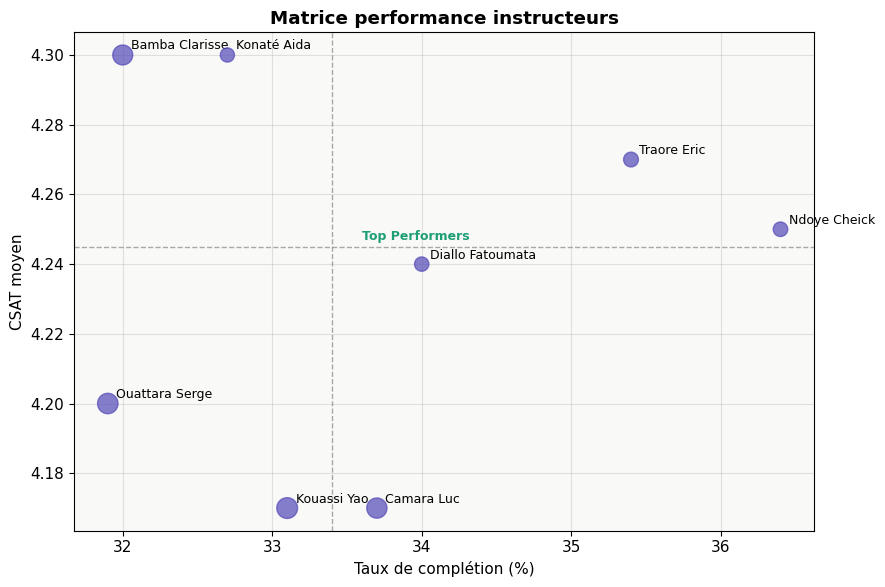

✅ Sauvegardé : ./outputs/matrice_instructeurs.png


In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(df_inst['taux_completion'], df_inst['csat_moyen'],
           s=df_inst['nb_apprenants']/5, c=COLORS['primary'], alpha=0.7, zorder=5)
med_comp = df_inst['taux_completion'].median()
med_csat = df_inst['csat_moyen'].median()
ax.axvline(med_comp, color=COLORS['neutral'], linestyle='--', linewidth=1, alpha=0.7)
ax.axhline(med_csat, color=COLORS['neutral'], linestyle='--', linewidth=1, alpha=0.7)
for _, row in df_inst.iterrows():
    ax.annotate(row['instructeur'], (row['taux_completion'], row['csat_moyen']),
                textcoords='offset points', xytext=(6, 4), fontsize=9)
ax.text(med_comp + 0.2, med_csat + 0.002, 'Top Performers',
        color=COLORS['secondary'], fontsize=9, fontweight='bold')
ax.set_xlabel('Taux de complétion (%)')
ax.set_ylabel('CSAT moyen')
ax.set_title('Matrice performance instructeurs', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}matrice_instructeurs.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Sauvegardé : {SAVE_PATH}matrice_instructeurs.png')

---
## Étape 5 — Heatmap activité heure × jour

### MÉTHODE
On extrait le `dayofweek` (0=Lundi à 6=Dimanche) de chaque date de session, puis on pivote pour obtenir une matrice heure × jour. La heatmap révèle les pics d'activité pour optimiser les campagnes relance et la disponibilité du support pédagogique.

> **Pourquoi pandas ici et non DuckDB ?** Le pivot et la visualisation matplotlib nécessitent un DataFrame — on passe par pandas directement plutôt que d'extraire depuis DuckDB puis repivot.

In [10]:
# Charger sessions en pandas pour la heatmap
import pandas as pd
df_sess = pd.read_csv(BASE_URL + 'sessions.csv', parse_dates=['date_session'])

JOURS = {0: 'Lun', 1: 'Mar', 2: 'Mer', 3: 'Jeu', 4: 'Ven', 5: 'Sam', 6: 'Dim'}
df_sess['jour_semaine'] = df_sess['date_session'].dt.dayofweek

hm = (
    df_sess.groupby(['heure_connexion', 'jour_semaine'])['session_id']
    .count().reset_index()
    .rename(columns={'session_id': 'nb_sessions'})
)
pivot = hm.pivot(index='heure_connexion', columns='jour_semaine', values='nb_sessions').fillna(0)
pivot.columns = [JOURS[c] for c in pivot.columns]

top3 = hm.nlargest(3, 'nb_sessions')
top3['jour_nom'] = top3['jour_semaine'].map(JOURS)
print('Top 3 créneaux d\'activité :')
for _, r in top3.iterrows():
    print(f'  {r["jour_nom"]} {int(r["heure_connexion"])}h : {int(r["nb_sessions"])} sessions')

Top 3 créneaux d'activité :
  Dim 21h : 539 sessions
  Ven 20h : 525 sessions
  Dim 17h : 524 sessions


> **INTERPRÉTATION — Les 3 créneaux les plus actifs :**
>
> - **Dimanche 21h : 539 sessions** — le pic absolu
> - **Vendredi 20h : 525 sessions**
> - **Dimanche 17h : 524 sessions**
>
> **MÉTIER :** Les apprenants EduTrack se connectent principalement **le soir (18h-22h) et le weekend**. Ce sont des professionnels en activité qui apprennent sur leur temps libre. Conséquences opérationnelles :
> - Les emails de relance doivent être envoyés **vendredi 18h** (avant le pic weekend)
> - Le support live doit être disponible **dimanche après-midi et soir**
> - Les nouvelles leçons devraient sortir **le jeudi** pour être disponibles au peak weekend

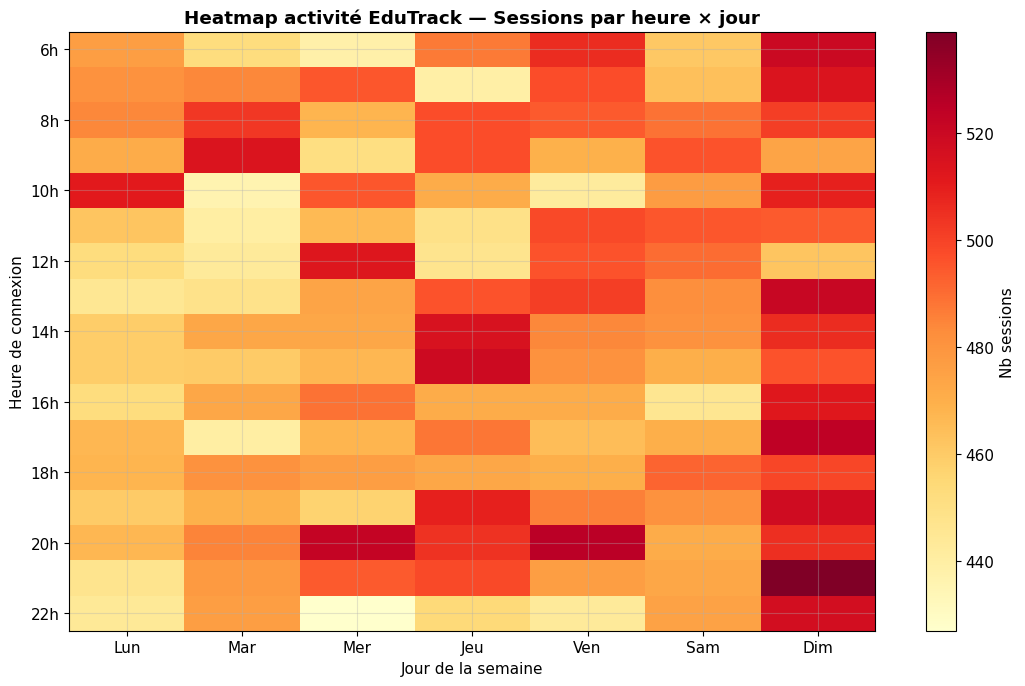

✅ Sauvegardé : ./outputs/heatmap_activite.png


In [11]:
fig, ax = plt.subplots(figsize=(11, 7))
im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(0, len(pivot.index), 2))
ax.set_yticklabels([f'{h}h' for h in pivot.index[::2]])
ax.set_title('Heatmap activité EduTrack — Sessions par heure × jour', fontweight='bold')
ax.set_xlabel('Jour de la semaine')
ax.set_ylabel('Heure de connexion')
plt.colorbar(im, ax=ax, label='Nb sessions')
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}heatmap_activite.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Sauvegardé : {SAVE_PATH}heatmap_activite.png')

---
## Étape 6 — Tendance mensuelle des abandons avec LAG()

### MÉTHODE
`LAG()` est une window function SQL qui retourne la valeur de la ligne précédente dans une partition ordonnée. Ici, `LAG(taux_abandon)` sur la dimension temps permet de calculer la variation mensuelle du taux d'abandon : `variation = taux_actuel - taux_mois_précédent`.

> **DuckDB :** `strftime(date_inscription, '%Y-%m')` extrait l'année-mois depuis une date — équivalent de `dt.to_period('M')` en pandas.

In [12]:
%%sql df_aband <<
WITH mensuel AS (
    SELECT
        strftime(date_inscription, '%Y-%m')                                  AS mois,
        COUNT(inscription_id)                                                AS nb_inscr,
        SUM(CASE WHEN statut = 'Abandonne' THEN 1 ELSE 0 END)               AS nb_aband
    FROM inscriptions
    GROUP BY strftime(date_inscription, '%Y-%m')
)
SELECT
    mois,
    nb_inscr,
    nb_aband,
    ROUND(nb_aband * 100.0 / NULLIF(nb_inscr, 0), 1)                        AS taux_abandon,
    ROUND(
        nb_aband * 100.0 / NULLIF(nb_inscr, 0)
        - LAG(nb_aband * 100.0 / NULLIF(nb_inscr, 0)) OVER (ORDER BY mois)
    , 1)                                                                     AS variation
FROM mensuel
ORDER BY mois

In [17]:
df_aband

,mois,nb_inscr,nb_aband,taux_abandon,variation,mois_dt
0,2022-01,452,91.00,20.10,NaN,2022-01-01
1,2022-02,397,78.00,19.60,-0.50,2022-02-01
2,2022-03,364,65.00,17.90,-1.80,2022-03-01
3,2022-04,390,81.00,20.80,2.90,2022-04-01
4,2022-05,347,72.00,20.70,-0.00,2022-05-01
5,2022-06,347,70.00,20.20,-0.60,2022-06-01
6,2022-07,298,66.00,22.10,2.00,2022-07-01
7,2022-08,283,58.00,20.50,-1.70,2022-08-01
8,2022-09,266,49.00,18.40,-2.10,2022-09-01
9,2022-10,250,49.00,19.60,1.20,2022-10-01


> **INTERPRÉTATION :**
> - Taux d'abandon moyen sur 30 mois : **~19-21%** par mois
> - **Pic mars 2023 : 25.5%** — un quart des inscriptions de ce mois ont abandonné
> - Les taux d'abandon sont relativement stables, sans amélioration tendancielle
>
> **MÉTIER :** L'absence d'amélioration du taux d'abandon sur 30 mois confirme que le problème est structurel, pas conjoncturel. EduTrack n'a pas encore trouvé le levier pour réduire durablement ce taux. C'est précisément l'objectif du système d'alerte ML : identifier les apprenants à risque assez tôt pour intervenir avec une relance personnalisée.

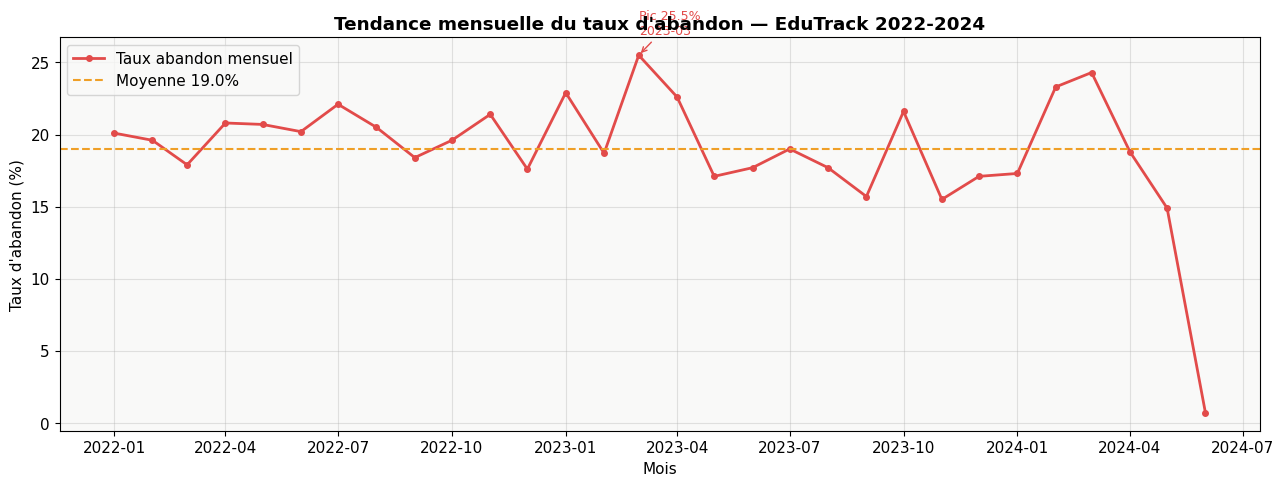

✅ Sauvegardé : ./outputs/tendance_abandon.png


In [13]:
fig, ax = plt.subplots(figsize=(13, 5))
df_aband['mois_dt'] = pd.to_datetime(df_aband['mois'])
ax.plot(df_aband['mois_dt'], df_aband['taux_abandon'],
        color=COLORS['danger'], linewidth=2, marker='o', markersize=4,
        label='Taux abandon mensuel')
ax.axhline(df_aband['taux_abandon'].mean(), color=COLORS['warning'],
           linestyle='--', linewidth=1.5,
           label=f"Moyenne {df_aband['taux_abandon'].mean():.1f}%")
pic = df_aband.nlargest(1, 'taux_abandon')
ax.annotate(f"Pic {pic['taux_abandon'].values[0]}%\n{pic['mois'].values[0]}",
            xy=(pic['mois_dt'].values[0], pic['taux_abandon'].values[0]),
            xytext=(0, 15), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color=COLORS['danger']),
            color=COLORS['danger'], fontsize=9)
ax.set_xlabel('Mois')
ax.set_ylabel('Taux d\'abandon (%)')
ax.set_title('Tendance mensuelle du taux d\'abandon — EduTrack 2022-2024', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}tendance_abandon.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Sauvegardé : {SAVE_PATH}tendance_abandon.png')

---
## Bilan du Notebook 3

| Question business | Réponse |
|---|---|
| Parcours meilleur complétion | **HTML CSS JavaScript (36.9%)** |
| Parcours taux abandon le plus élevé | **Machine Learning Appliqué (19.6%)** |
| Instructeur le mieux noté CSAT | **Bamba Clarisse / Konaté Aida (4.30/5)** |
| Créneau d'activité le plus élevé | **Dimanche 21h (539 sessions)** |
| Mois pic d'abandon | **Mars 2023 (25.5%)** |

### Patterns SQL maîtrisés

| Pattern | Utilisation |
|---|---|
| `RANK() OVER (ORDER BY)` | Classement parcours et instructeurs |
| `TRY_CAST(csat AS DOUBLE)` | Cast sécurisé sur colonne nullable |
| `COUNT(CASE WHEN ... END)` | KPI conditionnel dans une seule requête |
| `LAG() OVER (ORDER BY mois)` | Variation mensuelle du taux d'abandon |
| `strftime(date, '%Y-%m')` | Extraction mois depuis une date |
| `NULLIF(x, 0)` | Protection division par zéro |

**Pour le NB4 :** Utiliser les fichiers PNG exportés et `inscriptions_analytics.csv` pour construire le dashboard Power BI.

---

**DataProjectLab** — apprendre la data sur des cas concrets, structurés et orientés métier.